# Quiz: Unsupervised Learning

Selamat Anda sudah menyelesaikan materi **Unsupervised Learning**! Kami akan melakukan penilaian berupa kuis untuk menguji materi yang sudah dipelajari.

---

In [1]:
import importlib
import warnings
from pylab import rcParams

# for data manipulation
import pandas as pd 
# for matrix-based computation
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

# Scaler
from sklearn.preprocessing import StandardScaler

# clustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# Gower matrix
import gower as go

# custom functions
from helper import plot_elbow_kmeans, plot_elbow_kmedoids, biplot_kmeans, plot_depth_readings_cluster

In [2]:
# pandas display and formatting option
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
warnings.simplefilter(action='ignore', category=FutureWarning)

## Clustering

### K-Means

Pada bagian ini, Anda diminta untuk melakukan clustering lapisan batuan berdasarkan hasil pembacaan logging tools pada sumur minyak 15/9-19. Sumur ini merupakan bagian dari blok produksi di laut utara Norwegia yang dioperasikan oleh Statoil.

```
Top Depth (STRT): 102.1568
Bottom Depth (STOP): 4636.514
Depth Increment (STEP): 0.1524
Null Value (NULL): -999.25
Field Name (FLD): Q15
NAME (WELL): 15/9-19
WELLBORE (WBN): 15/9-19 SR
COUNTRY (NATI): NOR
COUNTRY (CTRY): NOR
OPERATOR (COMP): STATOIL
PERM DATUM (PDAT): MSL
RIG NAME (COUN): NORTH SEA
STATE (STAT): NORWAY
PB WELL ID (PBWE): 15/9-19
PB WELLBORE ID (APIN): 15/9-19 SR
PB WELL NAME SET (PBWS): ALL
```

Silakan jalankan kode di bawah ini untuk membaca data yang disimpan dengan nama `well_15_9_19.csv` pada folder `data_input`!

In [3]:
# membaca data
well = pd.read_csv('data_input/well_15_9_19.csv')

# 5 observasi pertama
well.head()

,DEPT,AC,CALI,DEN,GR,NEU,RDEP,RMED
0,3615.434,95.795,12.725,2.343,54.875,44.574,0.894,0.836
1,3615.586,94.227,12.596,2.353,53.516,62.110,0.737,0.803
2,3615.739,101.325,13.763,2.317,48.980,71.909,0.642,0.796
3,3615.891,99.567,14.325,2.259,36.676,44.899,0.657,0.793
4,3616.044,100.597,11.143,2.211,40.463,49.574,0.744,0.794


Berikut adalah penjelasan dari setiap kolomnya.

* `DEPT`: kedalaman saat pembacaan dengan logging tools (m).
* `AC`: sonic transit time (µs/ft).
* `CALI`: caliper log (inch).
* `DEN`: bulk density log (g/cc).
* `GR`: gamma ray log (GAPI).
* `NEU`: neutron porosity log(%).
* `RDEP`: deep resistivity log (Ω.m).
* `RMED`: medium resistivity log (Ω.m).

In [4]:
# informasi dataframe
well.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6579 entries, 0 to 6578
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    6579 non-null   float64
 1   AC      6579 non-null   float64
 2   CALI    6579 non-null   float64
 3   DEN     6579 non-null   float64
 4   GR      6579 non-null   float64
 5   NEU     6579 non-null   float64
 6   RDEP    6579 non-null   float64
 7   RMED    6579 non-null   float64
dtypes: float64(8)
memory usage: 411.3 KB


Pertama, lakukan subsetting pada kolom-kolom yang diperlukan untuk clustering: `DEPT`, `NEU`, `DEN`, dan `GR`. Simpan dalam variabel `well_clust`.

In [6]:
# subsetting kolom yang diperlukan
well_clust = well[['DEPT','NEU','DEN','GR']]
well_clust.head()

,DEPT,NEU,DEN,GR
0,3615.434,44.574,2.343,54.875
1,3615.586,62.110,2.353,53.516
2,3615.739,71.909,2.317,48.980
3,3615.891,44.899,2.259,36.676
4,3616.044,49.574,2.211,40.463


Selanjutnya, lakukan scaling pada setiap kolom yang terdapat pada `well_clust` dan simpan di dalam variabel `well_clust_scaled`.

In [7]:
well_clust_scaled = well_clust.copy()
cols = well_clust.columns

In [9]:
# membuat object untuk scaling
scaler = StandardScaler

In [10]:
# melakukan scaling
well_clust_scaled[cols] =StandardScaler().fit_transform(well_clust[cols])
well_clust_scaled.head()

,DEPT,NEU,DEN,GR
0,-1.732,2.259,-0.713,0.710
1,-1.731,3.749,-0.653,0.659
2,-1.731,4.581,-0.872,0.490
3,-1.730,2.286,-1.229,0.032
4,-1.730,2.683,-1.521,0.173


In [11]:
# range data setelah di-scaling
well_clust_scaled.describe()

,DEPT,NEU,DEN,GR
count,6579.000,6579.000,6579.000,6579.000
mean,-0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.732,-1.343,-2.580,-1.231
25%,-0.866,-0.665,-0.736,-0.791
50%,0.000,-0.240,0.342,-0.153
75%,0.866,0.434,0.801,0.557
max,1.732,10.905,3.313,10.002


1. Setelah dilakukan clustering dengan K-Means (`n_clusters = 8`) pada data log (`NEU`, `DEN`, `GR`), langkah **scaling** dilakukan sebelum proses clustering. Tujuan utama dari scaling adalah …

* [ ] Membuat data lebih mudah divisualisasikan dalam bentuk grafik.
* [ ] Mengurangi jumlah cluster yang terbentuk.
* [ ] Menyamakan skala antar variabel agar tidak ada yang lebih dominan.
* [ ] Meningkatkan nilai akurasi dari algoritma K-Means.

Setelah kita melakukan scaling, selanjutnya, kita akan melakukan clustering menggunakan K-Means. 

Buatlah sebuah model K-Means dengan `n_clusters = 8` dan `random_state = 2024`.

In [14]:
# membuat model K-means
kmeans = KMeans(n_clusters=8, random_state=2024)
kmeans.fit(well_clust_scaled[cols])

KMeans(random_state=2024)

Kemudian, assign label hasil pemodelan ke data asli, `well_clust`.

In [15]:
# meng-assign label hasil clustering ke data asli
well_clust['CLUSTER'] = kmeans.labels_

In [16]:
well_clust.head()

,DEPT,NEU,DEN,GR,CLUSTER
0,3615.434,44.574,2.343,54.875,0
1,3615.586,62.110,2.353,53.516,0
2,3615.739,71.909,2.317,48.980,0
3,3615.891,44.899,2.259,36.676,0
4,3616.044,49.574,2.211,40.463,0


Selanjutnya, kita perlu melakukan interpretasi dari hasil clustering. Jalankan kedua kode di bawah ini untuk membandingkan karakteristik `NEU` dan `DEN` dari setiap cluster.

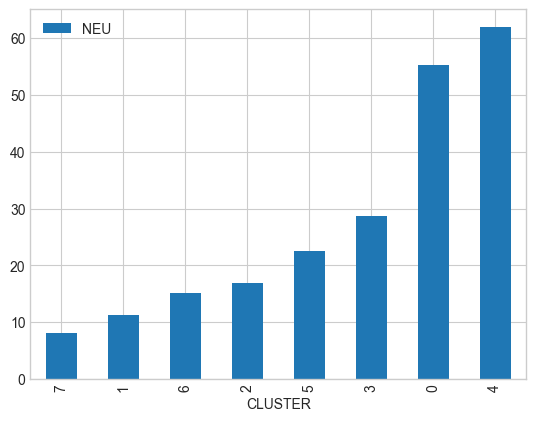

In [17]:
# neutron porosity
well_clust[['NEU','CLUSTER']].groupby('CLUSTER').mean().\
                                        sort_values(by = 'NEU', ascending = True).\
                                        plot(kind = 'bar');

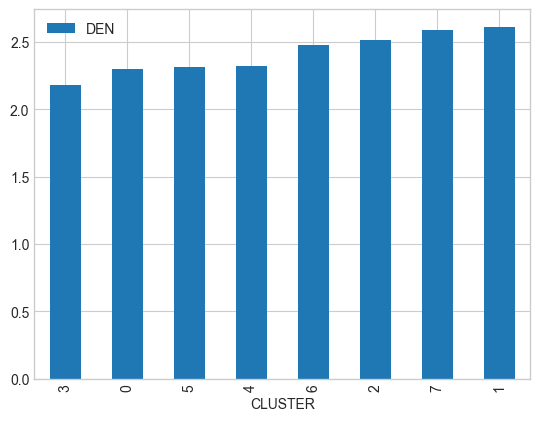

In [18]:
# bulk density
well_clust[['DEN','CLUSTER']].groupby('CLUSTER').mean().\
                                        sort_values(by = 'DEN', ascending = True).\
                                        plot(kind = 'bar');

2. Berdasarkan plot di atas, pernyataan **yang benar** adalah ...

- [ ] Cluster 4 memiliki rata-rata neutron porosity tertinggi dan rata-rata bulk density terendah keempat.
- [ ] Cluster 0 sama-sama memiliki rata-rata neutron porosity dan bulk density yang rendah.
- [ ] Cluster 7 memiliki karakteristik neutron porosity dan bulk density yang sama dengan cluster 5.
- [ ] Cluster 1 memiliki karakteristik neutron porosity dan bulk density yang sama dengan cluster 3.

Salah satu cara untuk menentukan nilai `k` yang akan menghasilkan hasil clustering terbaik adalah dengan menggunakan **Elbow Method**. Perhatikan plot Elbow Method berikut:

![Elbow.png](data_input/Elbow.png)

3. Berdasarkan plot diatas, berapakah nilai `k` yang paling baik untuk digunakan?

- [ ] 3
- [ ] 4
- [ ] 9
- [ ] 10

### K-Medoids

4. Pernyataan yang **salah** mengenai K-Medoids adalah ...

- [ ] K-Medoids hanya bisa digunakan untuk data numerik.
- [ ] K-Medoids unggul dalam data yang memiliki outlier.
- [ ] K-Medoids dapat digunakan untuk data numerik dan data kategorik.
- [ ] K-Medoids termasuk ke dalam non-hierarchical clustering.

5. Ketika menggunakan algoritma K-Medoids pada data log sumur (`NEU`, `DEN`, `GR`), salah satu keuntungan dibandingkan K-Means adalah …

* [ ] K-Medoids lebih cepat karena menghitung rata-rata jarak antar data.
* [ ] K-Medoids cenderung lebih sensitif terhadap outlier.
* [ ] K-Medoids lebih robust terhadap outlier karena menggunakan titik data aktual sebagai pusat cluster.
* [ ] K-Medoids tidak dapat digunakan pada data log geofisika karena bersifat numerik.